# Progetto di Laboratorio di Intelligenza Artificiale
## Analisi del Dataset Wine con Tecniche Supervisionate e Non Supervisionate

**Componenti del gruppo:** Marco Barbera 555979 - Sebastiano Marino 559083 - Basilio Jan Sansiveri 556419
**Corso:** Laboratorio di Intelligenza Artificiale — A.A. 2025/2026

---
### Istruzioni per l'Esecuzione e Riproducibilità

- **Linguaggio:** Python 3 (testato su Python 3.11).
- **Librerie richieste:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`. Installabili con `pip install numpy pandas matplotlib seaborn scikit-learn`.
- **Esecuzione:** eseguire le celle in ordine dall'alto verso il basso. Il dataset Wine è incluso in scikit-learn, quindi non sono necessari file esterni.
- **Riproducibilità:** tutti i componenti stocastici (split train/test, K-Means, MLP) usano lo stesso seme `RANDOM_STATE = 42`. Gli iperparametri dei classificatori sono selezionati via `GridSearchCV` (5 fold) sul solo training set, garantendo risultati identici a ogni esecuzione.
---


## 1. Importazione delle Librerie

In [1]:
# Librerie standard e di utilità
import numpy as np                                          # operazioni numeriche su array multidimensionali
import pandas as pd                                         # manipolazione dati in formato tabellare
import warnings                                             # gestione dei warning Python
warnings.filterwarnings('ignore')                           # soppressione warning non critici per output pulito

# Visualizzazione
import matplotlib.pyplot as plt                             # grafici base (line plot, scatter, bar, ecc.)
import matplotlib.cm as cm                                  # colormap per i grafici
import seaborn as sns                                       # grafici statistici avanzati (heatmap, boxplot)

# Dataset
from sklearn.datasets import load_wine                      # dataset Wine UCI da scikit-learn

# Preprocessing
from sklearn.preprocessing import StandardScaler            # standardizzazione (media=0, std=1)
from sklearn.decomposition import PCA                       # analisi delle componenti principali
from sklearn.preprocessing import OneHotEncoder
# Clustering
from sklearn.cluster import KMeans                          # algoritmo K-Means
from sklearn.metrics import silhouette_score                # silhouette score medio (globale)
from sklearn.metrics import silhouette_samples              # silhouette score per singolo campione

# Classificazione
from sklearn.tree import DecisionTreeClassifier             # albero di decisione (modello baseline)
from sklearn.tree import plot_tree                          # visualizzazione grafica dell'albero
from sklearn.neural_network import MLPClassifier            # rete neurale MLP (modello principale)
from sklearn.model_selection import train_test_split        # divisione stratificata train/test
from sklearn.model_selection import cross_val_score         # validazione incrociata k-fold
from sklearn.model_selection import GridSearchCV            # ricerca degli iperparametri con CV

# Metriche di valutazione
from sklearn.metrics import (
    accuracy_score,                                         # accuratezza globale
    precision_score,                                        # precisione (macro-average)
    recall_score,                                           # recall (macro-average)
    f1_score,                                               # F1-score (macro-average)
    confusion_matrix,                                       # matrice di confusione grezza
    ConfusionMatrixDisplay                                  # visualizzazione grafica della matrice
)

# Impostazioni grafiche globali
plt.rcParams['figure.figsize'] = (11, 6)                    # dimensione di default delle figure
plt.rcParams['axes.titlesize'] = 14                         # dimensione del testo nei titoli
plt.rcParams['axes.labelsize'] = 12                         # dimensione delle etichette degli assi
plt.rcParams['xtick.labelsize'] = 10                        # dimensione etichette asse x
plt.rcParams['ytick.labelsize'] = 10                        # dimensione etichette asse y
sns.set_style("whitegrid")                                  # stile griglia bianca per tutti i grafici seaborn

RANDOM_STATE = 42                                           # seme globale per riproducibilità degli esperimenti

---
## 2. Caricamento ed Esplorazione del Dataset

In [2]:
wine_dataset = load_wine()                                       # caricamento del dataset Wine da sklearn

feature_names_list = list(wine_dataset.feature_names)            # lista dei nomi delle 13 feature chimiche
class_names_list   = list(wine_dataset.target_names)             # lista dei nomi delle 3 classi (cultivar)

# Creazione di un DataFrame pandas per facilitare l'esplorazione visiva
wine_dataframe = pd.DataFrame(
    wine_dataset.data,                                           # matrice dati (178 x 13)
    columns=feature_names_list                                   # intestazioni = nomi feature
)
wine_dataframe['target']     = wine_dataset.target              # aggiunta colonna con etichetta numerica (0,1,2)

feature_matrix = wine_dataset.data                               # array NumPy (178, 13): feature grezze
target_vector  = wine_dataset.target                             # array NumPy (178): etichette di classe

# Informazioni strutturali di base
print(f"  Dimensioni feature matrix : {feature_matrix.shape}")
print(f"  Numero di feature         : {len(feature_names_list)}")
print(f"  Numero di campioni        : {feature_matrix.shape[0]}")
print(f"  Numero di classi          : {len(class_names_list)}")
print("\nDistribuzione delle classi:")
class_counts = wine_dataframe['target'].value_counts()       # conteggio campioni per classe
for class_label, count in class_counts.items():
    percentage = count / len(wine_dataframe) * 100               # percentuale sul totale
    print(f"  {class_label:<20}: {count} campioni ({percentage:.1f}%)")

print("\nDescrizione features:")
print(wine_dataframe[feature_names_list].describe().T[['mean', 'std', 'min', 'max']])

print("\nStatistiche descrittive delle feature (prime 5 righe):")
wine_dataframe.head()

  Dimensioni feature matrix : (178, 13)
  Numero di feature         : 13
  Numero di campioni        : 178
  Numero di classi          : 3

Distribuzione delle classi:
  1                   : 71 campioni (39.9%)
  0                   : 59 campioni (33.1%)
  2                   : 48 campioni (27.0%)

Descrizione features:
                                    mean         std     min      max
alcohol                        13.000618    0.811827   11.03    14.83
malic_acid                      2.336348    1.117146    0.74     5.80
ash                             2.366517    0.274344    1.36     3.23
alcalinity_of_ash              19.494944    3.339564   10.60    30.00
magnesium                      99.741573   14.282484   70.00   162.00
total_phenols                   2.295112    0.625851    0.98     3.88
flavanoids                      2.029270    0.998859    0.34     5.08
nonflavanoid_phenols            0.361854    0.124453    0.13     0.66
proanthocyanins                 1.590899    0.5

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


---
## 3. Standardizzazione del Dataset

In [3]:
standard_scaler_full_dataset = StandardScaler()     # istanza dello StandardScaler

scaled_feature_matrix = standard_scaler_full_dataset.fit_transform(feature_matrix)  # calcolo media/std + trasformazione

# Verifica numerica della standardizzazione
post_scaling_means = np.abs(scaled_feature_matrix.mean(axis=0))  # medie post-scaling (devono essere ~0)
post_scaling_stds  = scaled_feature_matrix.std(axis=0)           # std post-scaling (devono essere ~1)

print("Verifica standardizzazione:")
print(f"  Media massima assoluta dopo lo scaling : {post_scaling_means.max():.2e}  (atteso: ~0)")
print(f"  Std  minima/massima dopo lo scaling    : {post_scaling_stds.min():.6f} / {post_scaling_stds.max():.6f}  (atteso: ~1)")



Verifica standardizzazione:
  Media massima assoluta dopo lo scaling : 7.84e-15  (atteso: ~0)
  Std  minima/massima dopo lo scaling    : 1.000000 / 1.000000  (atteso: ~1)


---
## 4. Clustering K-Means sulle Feature Originali Standardizzate

### Metodo del Gomito e Silhouette Score

  K =  2 | Inertia =  1658.76 | Silhouette = 0.2593
  K =  3 | Inertia =  1277.93 | Silhouette = 0.2849
  K =  4 | Inertia =  1175.43 | Silhouette = 0.2602
  K =  5 | Inertia =  1109.51 | Silhouette = 0.2016
  K =  6 | Inertia =  1046.00 | Silhouette = 0.2372
  K =  7 | Inertia =   981.60 | Silhouette = 0.2036
  K =  8 | Inertia =   935.20 | Silhouette = 0.1570
  K =  9 | Inertia =   889.89 | Silhouette = 0.1499
  K = 10 | Inertia =   845.90 | Silhouette = 0.1436


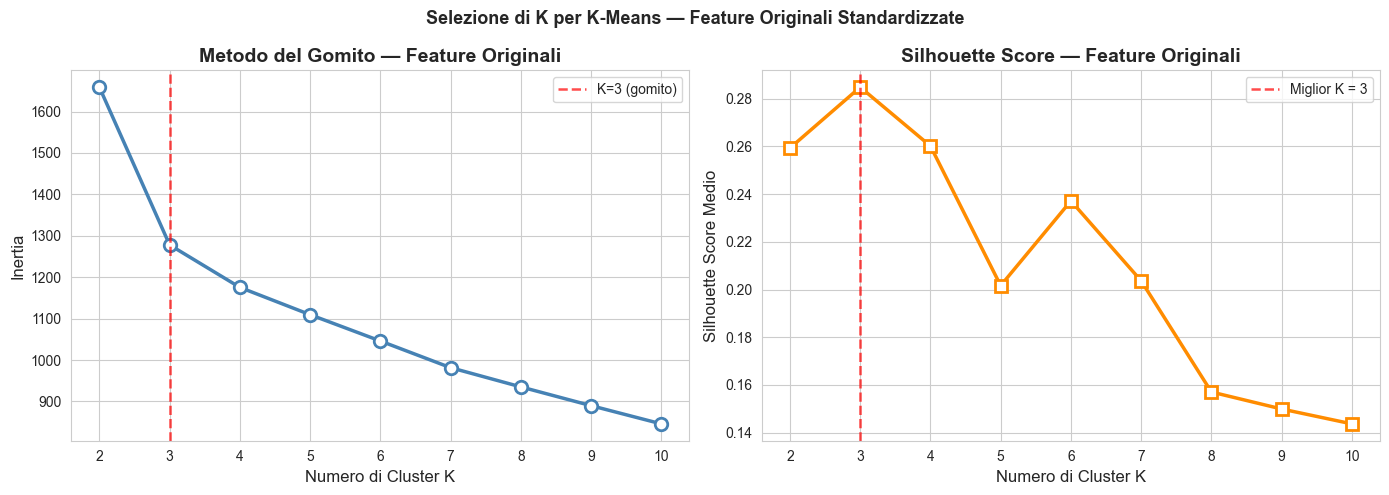


K suggerito dal Silhouette Score: 3
K suggerito dal Metodo del Gomito: 3
K scelto per il clustering finale: 3


In [4]:
inertia_values_for_original_features = []                        # lista delle inerzie per ogni K testato
silhouette_scores_for_original_features = []                     # lista dei silhouette score per ogni K testato
k_values_range = range(2, 11)                                    # range di K da testare (da 2 a 10 incluso)

def elbow_k_from_inertia(k_values, inertia):
    """K del gomito = punto di massima curvatura discreta (massima seconda differenza dell'inertia)."""
    ks = list(k_values)
    second_diff = [inertia[i - 1] - 2 * inertia[i] + inertia[i + 1] for i in range(1, len(inertia) - 1)]
    return ks[second_diff.index(max(second_diff)) + 1]

for k_candidate in k_values_range:
    kmeans_candidate = KMeans(
        n_clusters=k_candidate,                                   # numero di cluster corrente
        random_state=RANDOM_STATE,                                # seme per riproducibilità
        n_init=10                                                 # numero di inizializzazioni per stabilità
    )
    candidate_cluster_labels = kmeans_candidate.fit_predict(scaled_feature_matrix)              # fit + assegnazione cluster
    inertia_values_for_original_features.append(kmeans_candidate.inertia_)                      # salvataggio inertia
    candidate_silhouette = silhouette_score(scaled_feature_matrix, candidate_cluster_labels)    # silhouette score medio per questo K
    silhouette_scores_for_original_features.append(candidate_silhouette)
    print(f"  K = {k_candidate:2d} | Inertia = {kmeans_candidate.inertia_:8.2f} | Silhouette = {candidate_silhouette:.4f}")

# K scelto automaticamente dai grafici: gomito (curvatura dell'inertia) e silhouette
optimal_k_original_features = elbow_k_from_inertia(k_values_range, inertia_values_for_original_features)
best_k_original_features = list(k_values_range)[
    silhouette_scores_for_original_features.index(max(silhouette_scores_for_original_features))
]

# Grafico del Metodo del Gomito
fig, (ax_elbow, ax_silhouette) = plt.subplots(1, 2, figsize=(14, 5))

ax_elbow.plot(
    list(k_values_range),
    inertia_values_for_original_features,
    marker='o', color='steelblue', linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2
)
ax_elbow.set_xlabel('Numero di Cluster K')
ax_elbow.set_ylabel('Inertia')
ax_elbow.set_title('Metodo del Gomito — Feature Originali', fontweight='bold')
ax_elbow.set_xticks(list(k_values_range))
ax_elbow.axvline(x=optimal_k_original_features, color='red', linestyle='--', alpha=0.7, linewidth=1.8, label=f'K={optimal_k_original_features} (gomito)')
ax_elbow.legend()

# Grafico del Silhouette Score
ax_silhouette.plot(
    list(k_values_range),
    silhouette_scores_for_original_features,
    marker='s', color='darkorange', linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2
)
ax_silhouette.set_xlabel('Numero di Cluster K')
ax_silhouette.set_ylabel('Silhouette Score Medio')
ax_silhouette.set_title('Silhouette Score — Feature Originali', fontweight='bold')
ax_silhouette.set_xticks(list(k_values_range))
ax_silhouette.axvline(
    x=best_k_original_features, color='red', linestyle='--', alpha=0.7,
    linewidth=1.8, label=f'Miglior K = {best_k_original_features}'
)
ax_silhouette.legend()

plt.suptitle('Selezione di K per K-Means — Feature Originali Standardizzate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK suggerito dal Silhouette Score: {best_k_original_features}")
print(f"K suggerito dal Metodo del Gomito: {optimal_k_original_features}")
print(f"K scelto per il clustering finale: {optimal_k_original_features}")


### Motivazione della scelta di K = 3

Il grafico combinato evidenzia che **K = 3 è la scelta ottimale**.

La scelta è ulteriormente supportata dalla **conoscenza del dominio**: il dataset Wine rappresenta 3 vitigni 
distinti, quindi è ragionevole attendersi 3 gruppi naturali nei dati.

In [5]:
# Analisi dettagliata del silhouette per il K ottimale con grafico a barre per campione
kmeans_on_original_features = KMeans(                            # modello K-Means finale su feature originali
    n_clusters=optimal_k_original_features,
    random_state=RANDOM_STATE,
    n_init=10
)
cluster_labels_from_original = kmeans_on_original_features.fit_predict(scaled_feature_matrix)  # assegnazioni cluster

# Silhouette per ogni singolo campione
per_sample_silhouette_values = silhouette_samples(               # silhouette di ogni punto
    scaled_feature_matrix,
    cluster_labels_from_original
)
mean_silhouette_original = silhouette_score(                     # silhouette medio globale
    scaled_feature_matrix,
    cluster_labels_from_original
)


print(f"Silhouette Score medio finale (K={optimal_k_original_features}, feature originali): {mean_silhouette_original:.4f}")
print(f"Inertia finale: {kmeans_on_original_features.inertia_:.2f}")

Silhouette Score medio finale (K=3, feature originali): 0.2849
Inertia finale: 1277.93


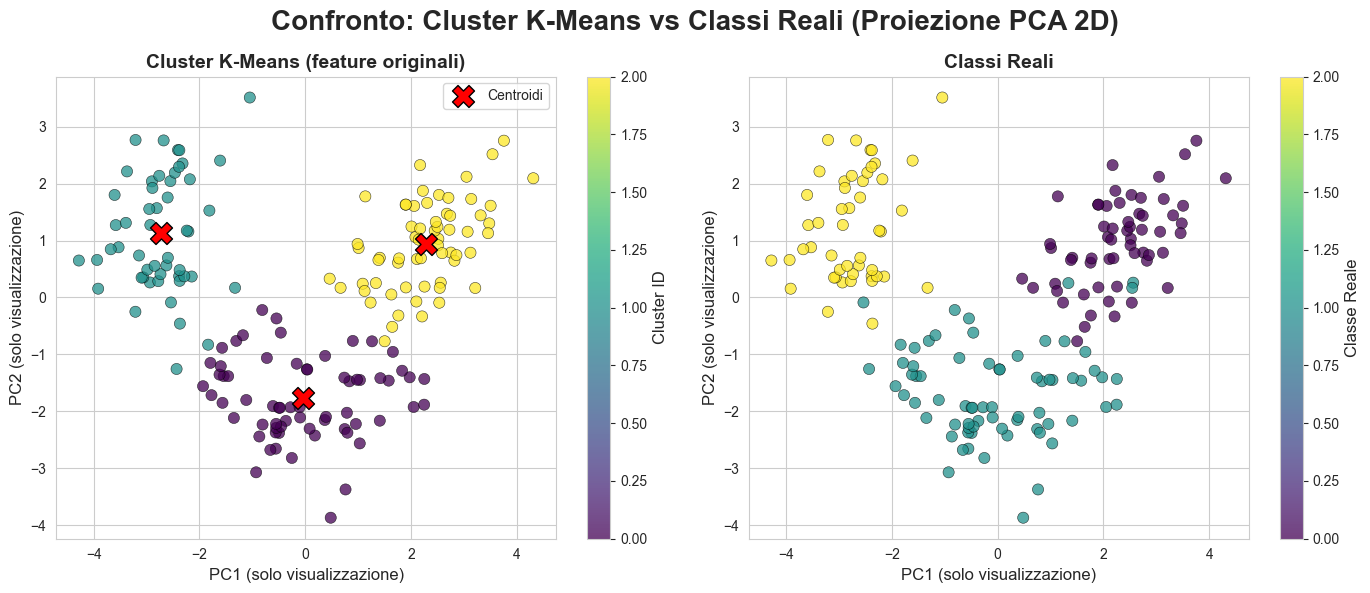


Tabella di Contingenza — Cluster K-Means vs Classi Reali (feature originali):
                 Classe 0 (class_0)  Classe 1 (class_1)  Classe 2 (class_2)
Cluster K-Means                                                            
0                                 0                  65                   0
1                                 0                   3                  48
2                                59                   3                   0


In [6]:
# Confronto visivo tra cluster trovati e classi reali
# Si usa una PCA 2D SOLO per la visualizzazione (non per il clustering)
pca_for_2d_visualization = PCA(n_components=2, random_state=RANDOM_STATE)   # PCA ausiliaria per visualizzare in 2D
coords_2d_for_visualization = pca_for_2d_visualization.fit_transform(scaled_feature_matrix)  # proiezione 2D

fig, (ax_cluster_view, ax_true_labels_view) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot sinistra: etichette dei cluster K-Means
scatter_clusters = ax_cluster_view.scatter(
    coords_2d_for_visualization[:, 0],
    coords_2d_for_visualization[:, 1],
    c=cluster_labels_from_original,                              # colorazione basata sul cluster assegnato
    cmap='viridis', edgecolors='k', alpha=0.75, s=65, linewidths=0.4
)
centroids_2d = pca_for_2d_visualization.transform(               # proiezione dei centroidi nello spazio 2D
    kmeans_on_original_features.cluster_centers_
)
ax_cluster_view.scatter(                                          # marcatori speciali per i centroidi
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='red', marker='X', s=250, zorder=5, edgecolors='black', linewidths=1, label='Centroidi'
)
ax_cluster_view.set_title('Cluster K-Means (feature originali)', fontweight='bold')
ax_cluster_view.set_xlabel('PC1 (solo visualizzazione)')
ax_cluster_view.set_ylabel('PC2 (solo visualizzazione)')
ax_cluster_view.legend()
plt.colorbar(scatter_clusters, ax=ax_cluster_view, label='Cluster ID')

# Subplot destra: classi reali
scatter_real = ax_true_labels_view.scatter(
    coords_2d_for_visualization[:, 0],
    coords_2d_for_visualization[:, 1],
    c=target_vector,                                             # colorazione basata sulla classe reale
    cmap='viridis', edgecolors='k', alpha=0.75, s=65, linewidths=0.4
)
ax_true_labels_view.set_title('Classi Reali', fontweight='bold')
ax_true_labels_view.set_xlabel('PC1 (solo visualizzazione)')
ax_true_labels_view.set_ylabel('PC2 (solo visualizzazione)')
plt.colorbar(scatter_real, ax=ax_true_labels_view, label='Classe Reale')

fig.suptitle('Confronto: Cluster K-Means vs Classi Reali (Proiezione PCA 2D)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabella di contingenza cluster vs classi reali
contingency_table_original = pd.crosstab(
    pd.Series(cluster_labels_from_original, name='Cluster K-Means'),
    pd.Series(target_vector, name='Classe Reale')
)
contingency_table_original.columns = [f'Classe {i} ({class_names_list[i]})' for i in range(3)]
print("\nTabella di Contingenza — Cluster K-Means vs Classi Reali (feature originali):")
print(contingency_table_original)

---
## 5. Clustering K-Means sulle Componenti PCA (2D)

In [7]:
# Riduzione dimensionale con PCA a 2 componenti principali
pca_2_components = PCA(n_components=2, random_state=RANDOM_STATE)         # PCA con 2 componenti
pca_2d_feature_matrix = pca_2_components.fit_transform(scaled_feature_matrix)  # trasformazione dataset

explained_variance_per_component = pca_2_components.explained_variance_ratio_  # varianza spiegata per componente
total_explained_variance = explained_variance_per_component.sum()               # varianza totale spiegata

print("Analisi della PCA a 2 componenti:")
print(f"  PC1 — Varianza spiegata: {explained_variance_per_component[0]*100:.2f}%")
print(f"  PC2 — Varianza spiegata: {explained_variance_per_component[1]*100:.2f}%")
print(f"  Totale varianza spiegata: {total_explained_variance*100:.2f}%")
print(f"  Varianza perduta:         {(1 - total_explained_variance)*100:.2f}%")

Analisi della PCA a 2 componenti:
  PC1 — Varianza spiegata: 36.20%
  PC2 — Varianza spiegata: 19.21%
  Totale varianza spiegata: 55.41%
  Varianza perduta:         44.59%


  K =  2 | Inertia =   628.79 | Silhouette = 0.4649
  K =  3 | Inertia =   259.51 | Silhouette = 0.5611
  K =  4 | Inertia =   192.39 | Silhouette = 0.4914
  K =  5 | Inertia =   155.19 | Silhouette = 0.4391
  K =  6 | Inertia =   122.71 | Silhouette = 0.4334
  K =  7 | Inertia =    99.39 | Silhouette = 0.4222
  K =  8 | Inertia =    89.29 | Silhouette = 0.4072
  K =  9 | Inertia =    80.74 | Silhouette = 0.3994
  K = 10 | Inertia =    74.16 | Silhouette = 0.4016


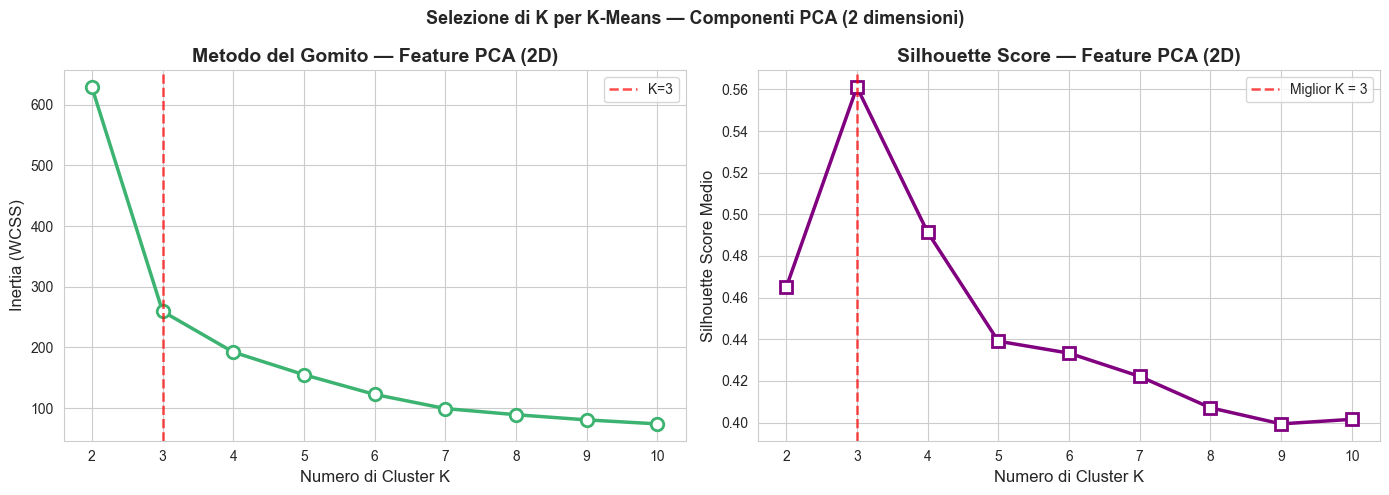


K suggerito dal Silhouette Score (PCA): 3


In [8]:
# Selezione del K ottimale per il clustering PCA con Elbow + Silhouette
inertia_values_for_pca_features = []                             # inerzie per i dati PCA
silhouette_scores_for_pca_features = []                          # silhouette per i dati PCA

for k_candidate in k_values_range:
    kmeans_pca_candidate = KMeans(
        n_clusters=k_candidate,
        random_state=RANDOM_STATE,
        n_init=10
    )
    pca_candidate_labels = kmeans_pca_candidate.fit_predict(pca_2d_feature_matrix)   # clustering sui dati PCA
    inertia_values_for_pca_features.append(kmeans_pca_candidate.inertia_)
    pca_candidate_silhouette = silhouette_score(                  # silhouette sui dati 2D
        pca_2d_feature_matrix,
        pca_candidate_labels
    )
    silhouette_scores_for_pca_features.append(pca_candidate_silhouette)
    print(f"  K = {k_candidate:2d} | Inertia = {kmeans_pca_candidate.inertia_:8.2f} | Silhouette = {pca_candidate_silhouette:.4f}")

best_k_pca_features = list(k_values_range)[                      # K con miglior silhouette sulle componenti PCA
    silhouette_scores_for_pca_features.index(max(silhouette_scores_for_pca_features))
]
# K dal metodo del gomito sull'inertia delle componenti PCA
optimal_k_pca_features = elbow_k_from_inertia(k_values_range, inertia_values_for_pca_features)

# Grafici Elbow e Silhouette per PCA
fig, (ax_pca_elbow, ax_pca_sil) = plt.subplots(1, 2, figsize=(14, 5))

ax_pca_elbow.plot(
    list(k_values_range), inertia_values_for_pca_features,
    marker='o', color='mediumseagreen', linewidth=2.5, markersize=9,
    markerfacecolor='white', markeredgewidth=2
)
ax_pca_elbow.axvline(x=optimal_k_pca_features, color='red', linestyle='--', alpha=0.7, linewidth=1.8, label=f'K={optimal_k_pca_features}')
ax_pca_elbow.set_xlabel('Numero di Cluster K')
ax_pca_elbow.set_ylabel('Inertia (WCSS)')
ax_pca_elbow.set_title('Metodo del Gomito — Feature PCA (2D)', fontweight='bold')
ax_pca_elbow.set_xticks(list(k_values_range))
ax_pca_elbow.legend()

ax_pca_sil.plot(
    list(k_values_range), silhouette_scores_for_pca_features,
    marker='s', color='purple', linewidth=2.5, markersize=9,
    markerfacecolor='white', markeredgewidth=2
)
ax_pca_sil.axvline(
    x=best_k_pca_features, color='red', linestyle='--', alpha=0.7,
    linewidth=1.8, label=f'Miglior K = {best_k_pca_features}'
)
ax_pca_sil.set_xlabel('Numero di Cluster K')
ax_pca_sil.set_ylabel('Silhouette Score Medio')
ax_pca_sil.set_title('Silhouette Score — Feature PCA (2D)', fontweight='bold')
ax_pca_sil.set_xticks(list(k_values_range))
ax_pca_sil.legend()

plt.suptitle('Selezione di K per K-Means — Componenti PCA (2 dimensioni)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK suggerito dal Silhouette Score (PCA): {best_k_pca_features}")

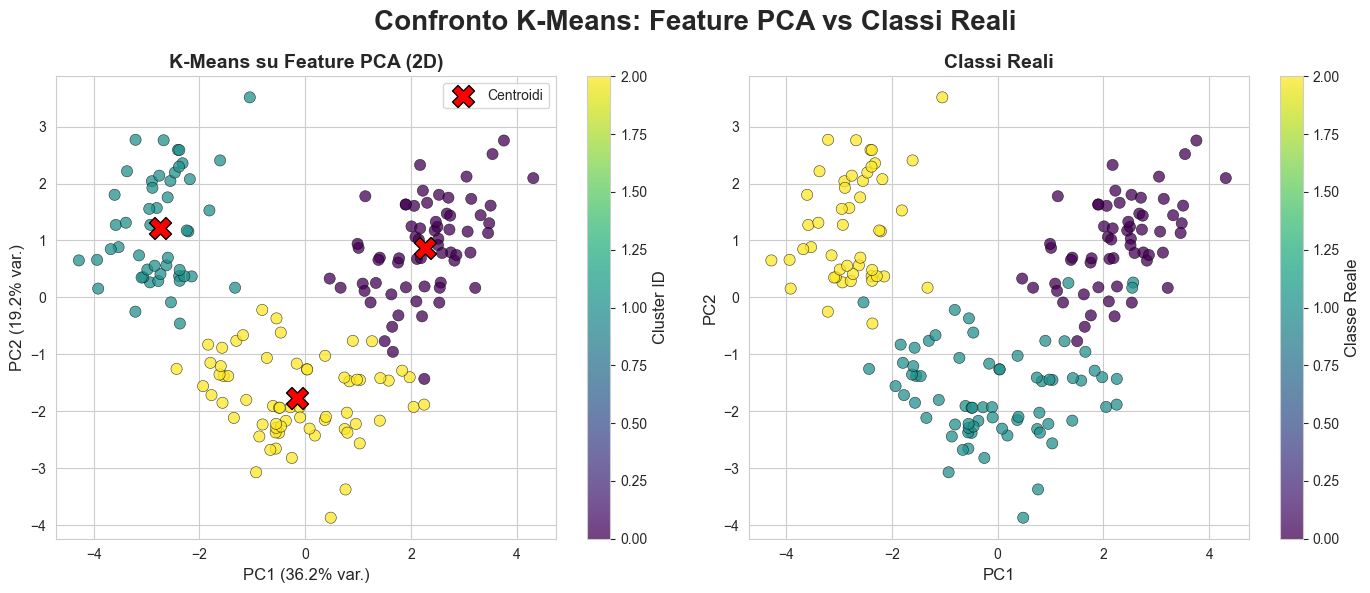


Tabella di Contingenza — Cluster PCA vs Classi Reali:
             Classe 0 (class_0)  Classe 1 (class_1)  Classe 2 (class_2)
Cluster PCA                                                            
0                            59                   5                   0
1                             0                   1                  48
2                             0                  65                   0


In [9]:
kmeans_on_pca_features = KMeans(                                 # modello K-Means finale sulle componenti PCA
    n_clusters=optimal_k_pca_features,
    random_state=RANDOM_STATE,
    n_init=10
)
cluster_labels_from_pca = kmeans_on_pca_features.fit_predict(pca_2d_feature_matrix)  # assegnazioni cluster PCA

# Visualizzazione del clustering PCA
fig, axes_pca_cluster = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: K-Means su feature PCA (i cluster sono direttamente nello spazio PCA)
pca_centroids_2d = kmeans_on_pca_features.cluster_centers_       # centroidi già nello spazio PCA 2D
scatter_pca = axes_pca_cluster[0].scatter(
    pca_2d_feature_matrix[:, 0], pca_2d_feature_matrix[:, 1],
    c=cluster_labels_from_pca, cmap='viridis', edgecolors='k', alpha=0.75, s=65, linewidths=0.4
)
axes_pca_cluster[0].scatter(
    pca_centroids_2d[:, 0], pca_centroids_2d[:, 1],
    c='red', marker='X', s=250, zorder=5, edgecolors='black', linewidths=1, label='Centroidi'
)
axes_pca_cluster[0].set_title('K-Means su Feature PCA (2D)', fontweight='bold')
axes_pca_cluster[0].set_xlabel(f'PC1 ({explained_variance_per_component[0]*100:.1f}% var.)')
axes_pca_cluster[0].set_ylabel(f'PC2 ({explained_variance_per_component[1]*100:.1f}% var.)')
axes_pca_cluster[0].legend()
plt.colorbar(scatter_pca, ax=axes_pca_cluster[0], label='Cluster ID')

# Subplot 2: classi reali
scatter_real_pca = axes_pca_cluster[1].scatter(
    pca_2d_feature_matrix[:, 0], pca_2d_feature_matrix[:, 1],
    c=target_vector, cmap='viridis', edgecolors='k', alpha=0.75, s=65, linewidths=0.4
)
axes_pca_cluster[1].set_title('Classi Reali', fontweight='bold')
axes_pca_cluster[1].set_xlabel('PC1')
axes_pca_cluster[1].set_ylabel('PC2')
plt.colorbar(scatter_real_pca, ax=axes_pca_cluster[1], label='Classe Reale')

fig.suptitle('Confronto K-Means: Feature PCA vs Classi Reali', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabella contingenza per PCA
contingency_table_pca = pd.crosstab(
    pd.Series(cluster_labels_from_pca, name='Cluster PCA'),
    pd.Series(target_vector, name='Classe Reale')
)
contingency_table_pca.columns = [f'Classe {i} ({class_names_list[i]})' for i in range(3)]
print("\nTabella di Contingenza — Cluster PCA vs Classi Reali:")
print(contingency_table_pca)

---
## 6. Classificazione — Preparazione

Suddivisione train/test stratificata, definizione delle griglie di iperparametri e delle funzioni di supporto, e costruzione delle feature aumentate (originali + cluster) usate sia dal Decision Tree sia dall'MLP.

In [10]:
# Suddivisione stratificata del dataset
(feature_train_raw, feature_test_raw, target_train, target_test) = train_test_split(
    feature_matrix,            # feature grezze (non ancora scalate)
    target_vector,             # etichette di classe
    test_size=0.25,            # 25% dei dati per il test set
    random_state=RANDOM_STATE, # seme per riproducibilità
    stratify=target_vector     # proporziona le classi in train e test
)

# StandardScaler riaddestrato SOLO sul training set
standard_scaler_for_classification = StandardScaler()   # scaler specifico per la classificazione

feature_train_scaled = standard_scaler_for_classification.fit_transform(feature_train_raw)  # fit sul train + trasformazione
feature_test_scaled = standard_scaler_for_classification.transform(feature_test_raw)        # solo trasformazione sul test (no fit: evita data leakage)

print("Suddivisione del dataset:")
print(f"  Training set : {feature_train_scaled.shape[0]} campioni  (75%)")
print(f"  Test set     : {feature_test_scaled.shape[0]} campioni  (25%)")
print(f"\nDistribuzione classi nel training set : {np.bincount(target_train)}")
print(f"Distribuzione classi nel test set     : {np.bincount(target_test)}")

Suddivisione del dataset:
  Training set : 133 campioni  (75%)
  Test set     : 45 campioni  (25%)

Distribuzione classi nel training set : [44 53 36]
Distribuzione classi nel test set     : [15 18 12]


In [11]:
# --- Griglie di iperparametri e funzioni di supporto per la model selection ---
# La ricerca avviene con GridSearchCV (5 fold stratificati, scoring=f1_macro) SOLO sul training set.
dt_param_grid = {
    'max_depth'       : [3, 4, 5, 6, None],
    'min_samples_leaf': [1, 2, 3, 5],
    'criterion'       : ['gini', 'entropy'],
}
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'alpha'             : [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 1e-2],
}

def tune_classifier(estimator, param_grid, X_tr, y_tr):
    """GridSearchCV a 5 fold (f1_macro) sul training set; ritorna l'oggetto search col modello già riaddestrato."""
    search = GridSearchCV(estimator, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
    search.fit(X_tr, y_tr)
    return search

def report_classifier(name, search, X_te, y_te):
    """Stampa CV (f1_macro) e metriche sul test set; ritorna (predizioni, modello)."""
    model = search.best_estimator_
    preds = model.predict(X_te)
    cv_std = search.cv_results_['std_test_score'][search.best_index_]
    print(name)
    print(f"  Migliori iperparametri    : {search.best_params_}")
    print(f"  F1-macro in CV (media±std): {search.best_score_:.4f} ± {cv_std:.4f}")
    print(f"  Accuracy sul test set     : {accuracy_score(y_te, preds):.4f}")
    print(f"  F1-macro sul test set     : {f1_score(y_te, preds, average='macro'):.4f}")

    # Classifica di tutte le configurazioni provate (F1-macro in CV):
    # così si vede che quella scelta è effettivamente la migliore.
    cv_results = pd.DataFrame(search.cv_results_)
    param_cols = [c for c in cv_results.columns if c.startswith('param_')]
    ranking = cv_results[param_cols + ['mean_test_score', 'std_test_score']].copy()
    ranking.columns = [c.replace('param_', '') for c in param_cols] + ['F1_CV_media', 'F1_CV_std']
    ranking = ranking.sort_values('F1_CV_media', ascending=False).reset_index(drop=True)
    ranking.insert(0, '', ['  --> scelto' if r == 0 else '' for r in range(len(ranking))])
    print(f"  Configurazioni valutate ({len(ranking)}) ordinate per F1-macro in CV:")
    print(ranking.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return preds, model


In [12]:
# K-Means addestrato SOLO sul training set
kmeans_for_feature_augmentation = KMeans(                        # K-Means addestrato solo sul train
    n_clusters=optimal_k_original_features,  # stesso K usato per il clustering iniziale
    random_state=RANDOM_STATE,
    n_init=10
)
kmeans_for_feature_augmentation.fit(feature_train_scaled)        # fit solo sul training set scalato

# Assegnazione dei cluster per training e test (separatamente, senza re-fit)
cluster_labels_train_augmented = kmeans_for_feature_augmentation.predict(   # etichette cluster per il train
    feature_train_scaled
)
cluster_labels_test_augmented = kmeans_for_feature_augmentation.predict(    # etichette cluster per il test
    feature_test_scaled
)

# One-hot encoding della label di cluster (encoder addestrato solo sul train, come scaler e K-Means)
onehot_cluster_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cluster_train_onehot = onehot_cluster_encoder.fit_transform(
    cluster_labels_train_augmented.reshape(-1, 1)   # serve una colonna 2D di forma (n, 1)
)
cluster_test_onehot = onehot_cluster_encoder.transform(
    cluster_labels_test_augmented.reshape(-1, 1)    # solo transform sul test (niente fit)
)

# Concatenazione: feature standardizzate + colonne one-hot del cluster
feature_train_augmented = np.column_stack([feature_train_scaled, cluster_train_onehot])
feature_test_augmented  = np.column_stack([feature_test_scaled,  cluster_test_onehot])

print("Dimensioni delle feature matrix aumentate (con one-hot):")
print(f"  Training aumentato : {feature_train_augmented.shape}  (era {feature_train_scaled.shape})")
print(f"  Test aumentato     : {feature_test_augmented.shape}  (era {feature_test_scaled.shape})")
print(f"\nCategorie apprese dall'encoder (ID cluster): {onehot_cluster_encoder.categories_[0]}")

Dimensioni delle feature matrix aumentate (con one-hot):
  Training aumentato : (133, 16)  (era (133, 13))
  Test aumentato     : (45, 16)  (era (45, 13))

Categorie apprese dall'encoder (ID cluster): [0 1 2]


---
## 7. Decision Tree (modello baseline)

Addestramento e valutazione del Decision Tree sulle feature originali e su quelle aumentate, con la visualizzazione degli alberi appresi.

In [13]:
# Decision Tree (baseline) — feature originali, iperparametri selezionati via CV
dt_search_original = tune_classifier(
    DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid,
    feature_train_scaled, target_train
)
dt_original_predictions, decision_tree_original = report_classifier(
    'Decision Tree — Feature Originali', dt_search_original, feature_test_scaled, target_test
)
print(f"  Profondità albero / foglie: {decision_tree_original.get_depth()} / {decision_tree_original.get_n_leaves()}")


Decision Tree — Feature Originali
  Migliori iperparametri    : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
  F1-macro in CV (media±std): 0.9055 ± 0.0813
  Accuracy sul test set     : 0.9556
  F1-macro sul test set     : 0.9565
  Configurazioni valutate (40) ordinate per F1-macro in CV:
             criterion max_depth  min_samples_leaf  F1_CV_media  F1_CV_std
  --> scelto      gini         3                 1       0.9055     0.0813
                  gini         4                 1       0.8989     0.0744
                  gini         6                 1       0.8989     0.0744
                  gini         5                 1       0.8989     0.0744
                  gini      None                 1       0.8989     0.0744
               entropy         3                 3       0.8975     0.0671
               entropy      None                 3       0.8975     0.0671
               entropy         6                 3       0.8975     0.0671
               entro

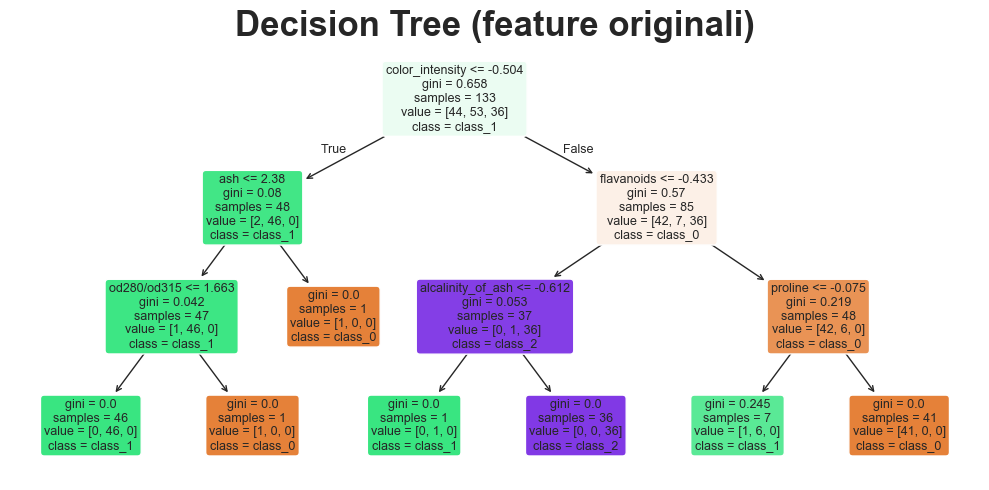

In [14]:
# Visualizzazione della struttura dell'albero baseline (interpretabilità)
plt.figure(figsize=(10, 5))
plot_tree(
    decision_tree_original,
    feature_names=[f.replace('od280/od315_of_diluted_wines', 'od280/od315') for f in feature_names_list],
    class_names=class_names_list,
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree (feature originali)', fontsize=25, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
# Decision Tree — feature originali + cluster (one-hot), iperparametri selezionati via CV
dt_search_augmented = tune_classifier(
    DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid,
    feature_train_augmented, target_train
)
dt_augmented_predictions, decision_tree_augmented = report_classifier(
    'Decision Tree — Feature Originali + Cluster (one-hot)', dt_search_augmented, feature_test_augmented, target_test
)
print(f"  Profondità albero / foglie: {decision_tree_augmented.get_depth()} / {decision_tree_augmented.get_n_leaves()}")


Decision Tree — Feature Originali + Cluster (one-hot)
  Migliori iperparametri    : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}
  F1-macro in CV (media±std): 0.9707 ± 0.0274
  Accuracy sul test set     : 0.9556
  F1-macro sul test set     : 0.9563
  Configurazioni valutate (40) ordinate per F1-macro in CV:
             criterion max_depth  min_samples_leaf  F1_CV_media  F1_CV_std
  --> scelto   entropy         4                 5       0.9707     0.0274
               entropy         5                 5       0.9707     0.0274
               entropy      None                 5       0.9707     0.0274
               entropy         6                 5       0.9707     0.0274
               entropy         3                 5       0.9707     0.0274
               entropy         6                 1       0.9702     0.0150
               entropy         5                 1       0.9702     0.0150
               entropy      None                 1       0.9702     0.01

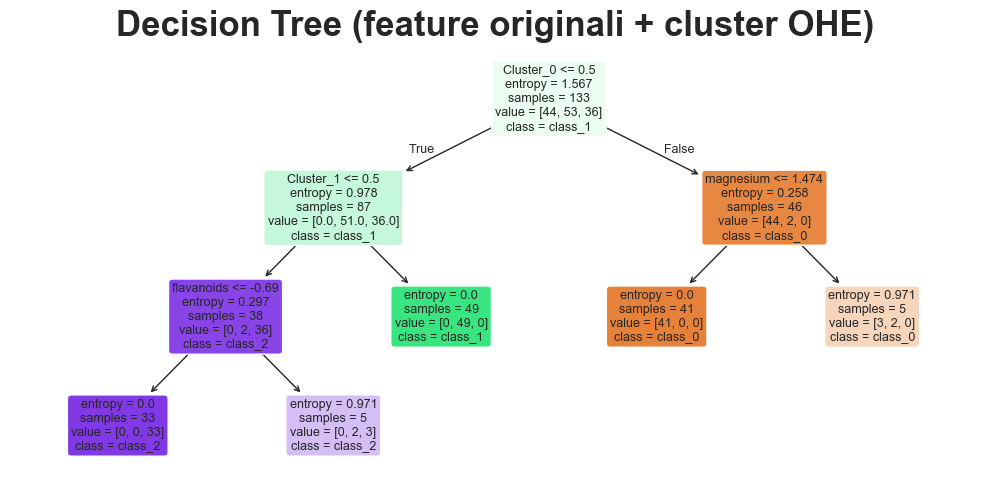

In [16]:
# Visualizzazione della struttura dell'albero aumentato (originali + cluster OHE)
plt.figure(figsize=(10, 5))

# Creiamo manualmente la lista unendo le feature originali ai 3 nuovi cluster
augmented_feature_names = feature_names_list + ['Cluster_0', 'Cluster_1', 'Cluster_2']

# Abbreviamo il nome lungo come in precedenza
augmented_names = [f.replace('od280/od315_of_diluted_wines', 'od280/od315') for f in augmented_feature_names]

plot_tree(
    decision_tree_augmented,
    feature_names=augmented_names,
    class_names=class_names_list,
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title('Decision Tree (feature originali + cluster OHE)', fontsize=25, fontweight='bold')
plt.tight_layout()
plt.show()

### Confronto Decision Tree: originale vs aumentato

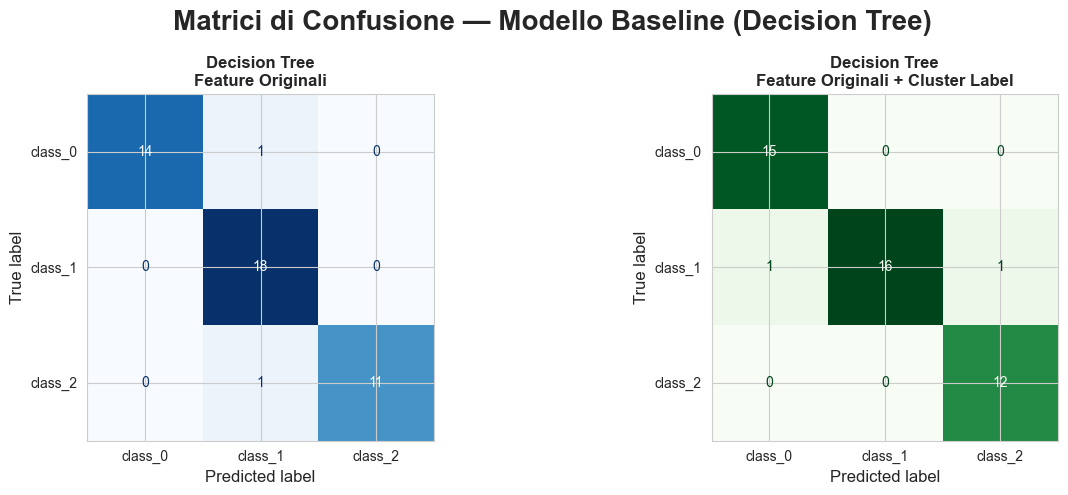

Confronto metriche — Decision Tree (Baseline):
                Accuracy  Precision  Recall  F1-Score
Modello                                              
DT — Originale    0.9556     0.9667   0.950    0.9565
DT — Aumentato    0.9556     0.9535   0.963    0.9563


In [17]:
# Funzione di supporto per calcolare tutte le metriche
def compute_classification_metrics(true_labels, predicted_labels, model_name: str) -> dict:
    """Calcola e restituisce le principali metriche di classificazione."""
    return {
        'Modello'   : model_name,
        'Accuracy'  : accuracy_score(true_labels, predicted_labels),                      # accuratezza globale
        'Precision' : precision_score(true_labels, predicted_labels, average='macro'),    # precisione macro
        'Recall'    : recall_score(true_labels, predicted_labels, average='macro'),       # recall macro
        'F1-Score'  : f1_score(true_labels, predicted_labels, average='macro'),           # F1 macro
    }

# Matrici di confusione Decision Tree 
fig, (ax_cm_dt_orig, ax_cm_dt_aug) = plt.subplots(1, 2, figsize=(13, 5))

confusion_matrix_dt_original = confusion_matrix(target_test, dt_original_predictions)
confusion_matrix_dt_augmented = confusion_matrix(target_test, dt_augmented_predictions)

display_dt_original = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_dt_original,
    display_labels=class_names_list
)
display_dt_augmented = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_dt_augmented,
    display_labels=class_names_list
)

display_dt_original.plot(ax=ax_cm_dt_orig, cmap='Blues', colorbar=False)
ax_cm_dt_orig.set_title('Decision Tree\nFeature Originali', fontweight='bold', fontsize=12)

display_dt_augmented.plot(ax=ax_cm_dt_aug, cmap='Greens', colorbar=False)
ax_cm_dt_aug.set_title('Decision Tree\nFeature Originali + Cluster Label', fontweight='bold', fontsize=12)

fig.suptitle('Matrici di Confusione — Modello Baseline (Decision Tree)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabella comparativa delle metriche Decision Tree
metrics_dt_original  = compute_classification_metrics(target_test, dt_original_predictions,  'DT — Originale')
metrics_dt_augmented = compute_classification_metrics(target_test, dt_augmented_predictions, 'DT — Aumentato')

metrics_comparison_dt = pd.DataFrame([metrics_dt_original, metrics_dt_augmented]).set_index('Modello')
print("Confronto metriche — Decision Tree (Baseline):")
print(metrics_comparison_dt.round(4).to_string())

---
## 8. MLP (modello principale)

Addestramento e valutazione dell'MLP sulle feature originali, su quelle aumentate con one-hot dei cluster e con le distanze dai centroidi.

In [18]:
# MLP (modello principale) — feature originali, iperparametri selezionati via CV
mlp_search_original = tune_classifier(
    MLPClassifier(activation='relu', solver='adam', max_iter=1000, random_state=RANDOM_STATE),
    mlp_param_grid, feature_train_scaled, target_train
)
mlp_original_predictions, mlp_original = report_classifier(
    'MLP — Feature Originali', mlp_search_original, feature_test_scaled, target_test
)


MLP — Feature Originali
  Migliori iperparametri    : {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
  F1-macro in CV (media±std): 0.9924 ± 0.0152
  Accuracy sul test set     : 0.9778
  F1-macro sul test set     : 0.9765
  Configurazioni valutate (18) ordinate per F1-macro in CV:
              alpha hidden_layer_sizes  learning_rate_init  F1_CV_media  F1_CV_std
  --> scelto 0.0001          (128, 64)              0.0010       0.9924     0.0152
             0.0001          (128, 64)              0.0100       0.9924     0.0152
             0.0100          (128, 64)              0.0100       0.9924     0.0152
             0.0100          (128, 64)              0.0010       0.9924     0.0152
             0.0010          (128, 64)              0.0100       0.9924     0.0152
             0.0010          (128, 64)              0.0010       0.9924     0.0152
             0.0001              (64,)              0.0100       0.9854     0.0180
             0.0001   

In [19]:
# MLP — feature originali + cluster (one-hot), iperparametri selezionati via CV
mlp_search_augmented = tune_classifier(
    MLPClassifier(activation='relu', solver='adam', max_iter=1000, random_state=RANDOM_STATE),
    mlp_param_grid, feature_train_augmented, target_train
)
mlp_augmented_predictions, mlp_augmented = report_classifier(
    'MLP — Feature Originali + Cluster (one-hot)', mlp_search_augmented, feature_test_augmented, target_test
)


MLP — Feature Originali + Cluster (one-hot)
  Migliori iperparametri    : {'alpha': 0.0001, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
  F1-macro in CV (media±std): 0.9924 ± 0.0152
  Accuracy sul test set     : 0.9778
  F1-macro sul test set     : 0.9765
  Configurazioni valutate (18) ordinate per F1-macro in CV:
              alpha hidden_layer_sizes  learning_rate_init  F1_CV_media  F1_CV_std
  --> scelto 0.0001              (64,)              0.0010       0.9924     0.0152
             0.0010              (64,)              0.0010       0.9924     0.0152
             0.0100              (64,)              0.0010       0.9924     0.0152
             0.0001              (64,)              0.0100       0.9854     0.0180
             0.0001          (128, 64)              0.0010       0.9854     0.0180
             0.0001           (64, 32)              0.0010       0.9854     0.0180
             0.0001          (128, 64)              0.0100       0.9854     0.0180
      

In [20]:
# Controllo di robustezza: feature derivate più ricche = distanze dai 3 centroidi (anziché il solo ID di cluster).
# Stesso K-Means addestrato solo sul training set -> nessun data leakage.
train_centroid_distances = kmeans_for_feature_augmentation.transform(feature_train_scaled)  # (n_train, 3)
test_centroid_distances  = kmeans_for_feature_augmentation.transform(feature_test_scaled)   # (n_test, 3)

feature_train_distances = np.column_stack([feature_train_scaled, train_centroid_distances])
feature_test_distances  = np.column_stack([feature_test_scaled,  test_centroid_distances])

mlp_search_distances = tune_classifier(
    MLPClassifier(activation='relu', solver='adam', max_iter=1000, random_state=RANDOM_STATE),
    mlp_param_grid, feature_train_distances, target_train
)
mlp_distances_predictions, mlp_distances = report_classifier(
    'MLP — Feature Originali + Distanze dai centroidi', mlp_search_distances, feature_test_distances, target_test
)


MLP — Feature Originali + Distanze dai centroidi
  Migliori iperparametri    : {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}
  F1-macro in CV (media±std): 0.9924 ± 0.0152
  Accuracy sul test set     : 0.9778
  F1-macro sul test set     : 0.9765
  Configurazioni valutate (18) ordinate per F1-macro in CV:
              alpha hidden_layer_sizes  learning_rate_init  F1_CV_media  F1_CV_std
  --> scelto 0.0010           (64, 32)              0.0100       0.9924     0.0152
             0.0001           (64, 32)              0.0100       0.9924     0.0152
             0.0100           (64, 32)              0.0100       0.9924     0.0152
             0.0001           (64, 32)              0.0010       0.9853     0.0180
             0.0001              (64,)              0.0100       0.9850     0.0184
             0.0001              (64,)              0.0010       0.9850     0.0184
             0.0010              (64,)              0.0100       0.9850     0.0184

### Confronto MLP: originale vs aumentato vs distanze

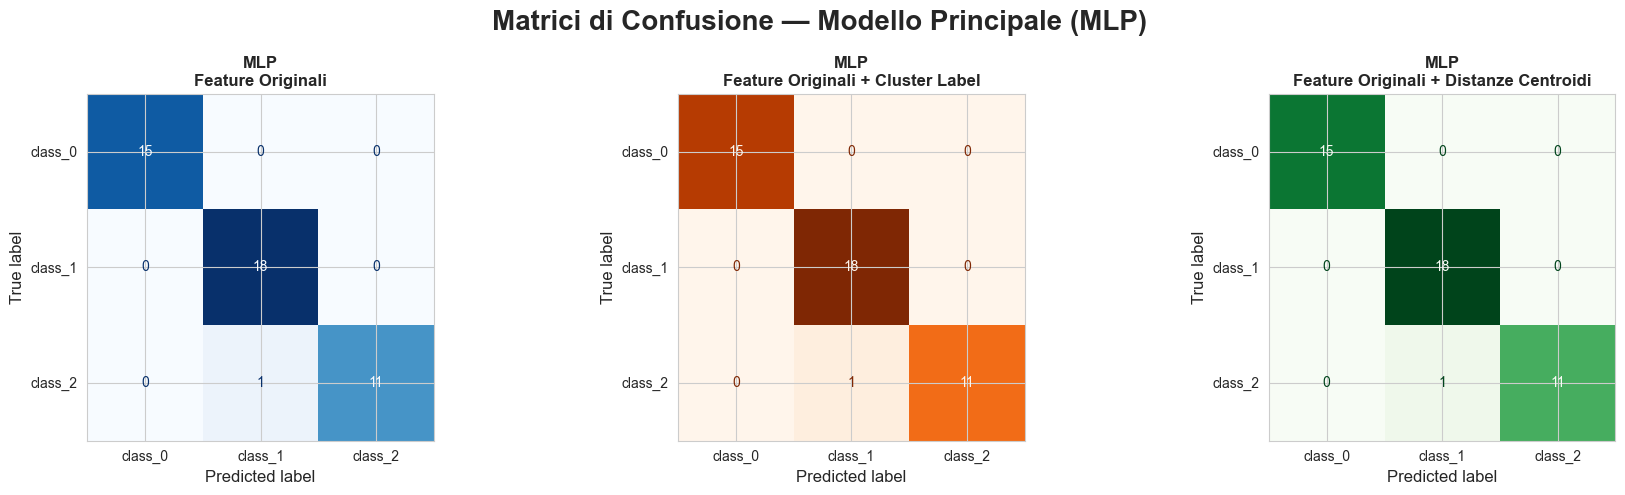

Confronto metriche — MLP (Modello Principale):
                       Accuracy  Precision  Recall  F1-Score
Modello                                                     
MLP — Originale          0.9778     0.9825  0.9722    0.9765
MLP — Aumentato          0.9778     0.9825  0.9722    0.9765
MLP — Orig + Distanze    0.9778     0.9825  0.9722    0.9765


In [21]:
# Matrici di confusione MLP — le tre configurazioni
fig, (ax_cm_mlp_orig, ax_cm_mlp_aug, ax_cm_mlp_dist) = plt.subplots(1, 3, figsize=(18, 5))

confusion_matrix_mlp_original  = confusion_matrix(target_test, mlp_original_predictions)
confusion_matrix_mlp_augmented = confusion_matrix(target_test, mlp_augmented_predictions)
confusion_matrix_mlp_distances = confusion_matrix(target_test, mlp_distances_predictions)

display_mlp_original = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_mlp_original,
    display_labels=class_names_list
)
display_mlp_augmented = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_mlp_augmented,
    display_labels=class_names_list
)
display_mlp_distances = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_mlp_distances,
    display_labels=class_names_list
)

display_mlp_original.plot(ax=ax_cm_mlp_orig, cmap='Blues', colorbar=False)
ax_cm_mlp_orig.set_title('MLP\nFeature Originali', fontweight='bold', fontsize=12)

display_mlp_augmented.plot(ax=ax_cm_mlp_aug, cmap='Oranges', colorbar=False)
ax_cm_mlp_aug.set_title('MLP\nFeature Originali + Cluster Label', fontweight='bold', fontsize=12)

display_mlp_distances.plot(ax=ax_cm_mlp_dist, cmap='Greens', colorbar=False)
ax_cm_mlp_dist.set_title('MLP\nFeature Originali + Distanze Centroidi', fontweight='bold', fontsize=12)

fig.suptitle('Matrici di Confusione — Modello Principale (MLP)', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabella comparativa delle metriche MLP
metrics_mlp_original  = compute_classification_metrics(target_test, mlp_original_predictions,  'MLP — Originale')
metrics_mlp_augmented = compute_classification_metrics(target_test, mlp_augmented_predictions, 'MLP — Aumentato')
metrics_mlp_distances = compute_classification_metrics(target_test, mlp_distances_predictions, 'MLP — Orig + Distanze')

metrics_comparison_mlp = pd.DataFrame([
    metrics_mlp_original,
    metrics_mlp_augmented,
    metrics_mlp_distances
]).set_index('Modello')
print("Confronto metriche — MLP (Modello Principale):")
print(metrics_comparison_mlp.round(4).to_string())

---
## 9. Confronto complessivo di tutti i modelli

Heatmap riassuntiva delle metriche (Accuracy, Precision, Recall, F1) per tutte e cinque le configurazioni.

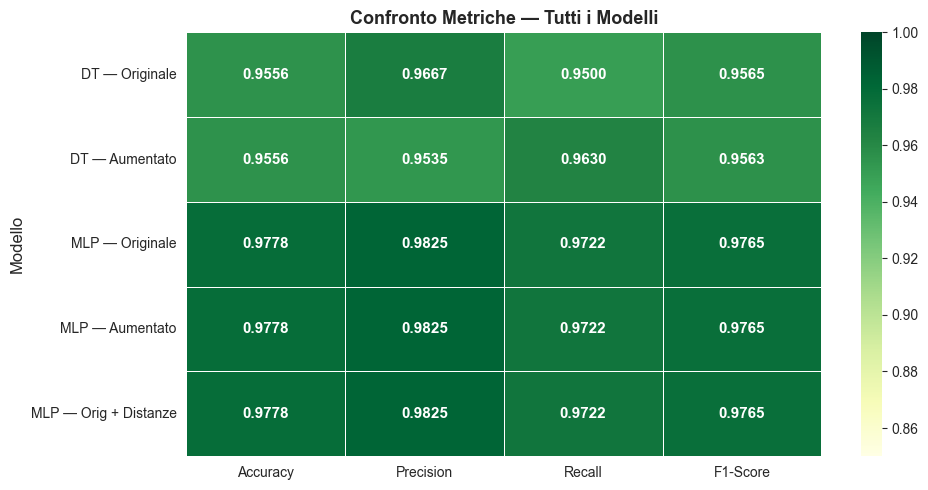

In [22]:
# Heatmap riassuntiva di tutte le configurazioni
metrics_mlp_distances = compute_classification_metrics(target_test, mlp_distances_predictions, 'MLP — Orig + Distanze')

all_metrics_summary = pd.DataFrame([
    metrics_dt_original,
    metrics_dt_augmented,
    metrics_mlp_original,
    metrics_mlp_augmented,
    metrics_mlp_distances
]).set_index('Modello')

fig, ax_summary = plt.subplots(figsize=(10, 5))
sns.heatmap(
    all_metrics_summary.astype(float),                           # conversione esplicita a float per heatmap
    annot=True,                                                  # mostra i valori numerici
    fmt='.4f',                                                   # 4 decimali
    cmap='YlGn',                                                 # colormap giallo-verde
    vmin=0.85, vmax=1.0,                                         # range significativo per i valori
    linewidths=0.5,
    ax=ax_summary,
    annot_kws={'size': 11, 'weight': 'bold'}
)
ax_summary.set_title('Confronto Metriche — Tutti i Modelli', fontsize=13, fontweight='bold')
ax_summary.set_xticklabels(ax_summary.get_xticklabels(), rotation=0)
ax_summary.set_yticklabels(ax_summary.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()
